# 1. Dataset

In [60]:
from torch.utils.data import Dataset
import cv2
import os
import numpy as np
import torch
from PIL import Image
import pandas as pd
import utils.transforms as T

def train_transform(size=(200,450)):
    return T.Compose([
    T.Breast_crop(),
    T.RandomHorizontalFlip(p=0.2),
    T.RandomVerticalFlip(p=0.2),
    T.Gaussian_noise(),
    T.Scale_box(),
    T.RandomResize([size]),
    T.ToTensor(),
])
Flip = T.RandomHorizontalFlip(p =1)
#train_transform = None
def valid_transform(size=(200,450)):
    return T.Compose([
    T.Breast_crop(),
    T.RandomResize([size]),
    T.ToTensor(),
])


def read_xray_png(path):
    # Read the PNG image using OpenCV
    data = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    
    # Normalize the image data to range [0, 255]
    # data = data - np.min(data)
    # data = data / np.max(data)
    # data = (data * 255).astype(np.float32)
    
    # Convert the grayscale image to RGB by repeating the grayscale values across 3 channels
    data = np.repeat(np.expand_dims(data, axis=2), 3, axis=2)
        
    return data

class MammoDetectionDataset(Dataset):
    def __init__(self,
                image_folder_path="/mnt/d/AiThings/SimCLRxConPro/Dataset/Mammo/mammo_dataset_ver4/archive/Processed_Images_450_200",
                annotation_path = "/mnt/d/AiThings/SimCLRxConPro/Dataset/Mammo/mammo_dataset_ver4/archive/finding_annotations.csv",
                breast_level_path = "/mnt/d/AiThings/SimCLRxConPro/Dataset/Mammo/mammo_dataset_ver4/archive/breast-level_annotations.csv",
                transforms = train_transform((200,450)),
                image_size = (200,450),
                classes =  ['__background__', 'Mass'],
                mode = "training"):

        self.transforms = transforms
        self.images_path = image_folder_path
        self.finding_path = annotation_path
        self.breast_level_path = breast_level_path
        self.img_size = image_size
        self.classes = classes
        self.all_image_paths = []
        self.log_annot_issue_x = True
        self.log_annot_issue_y = True
        self.mode = mode
        self.create_anno()

    def create_anno(self):
        finding = pd.read_csv(self.finding_path)
        breast_level = pd.read_csv(self.breast_level_path)

        # print(finding['finding_categories'].unique())
        finding_mass= (finding['finding_categories']).apply(lambda i: 'No Finding' not in i)
        #finding_mass = (finding['finding_categories']).apply(lambda i : 'Mass' in i or 'Suspicious Calcification' in i)
        #finding_mass = (finding['finding_categories']).apply(lambda i : 'Mass' in i)
        finding = finding[finding_mass]
        if self.mode == "training" :
            breast_level= breast_level[breast_level['split']== 'training']
            finding =finding[finding['split']== 'training']
        elif self.mode == "valid":
            breast_level= breast_level[breast_level['split']== 'valid']
            finding = finding[finding['split']== 'valid']

        else:
            breast_level= breast_level[breast_level['split']== 'test']
            finding = finding[finding['split']== 'test']
        self.image_id = breast_level[['study_id', 'image_id', 'view_position', 'laterality','height', 'width']].reset_index()
        #print(finding['image_id'])
        
        if self.mode == "training":
            image_id_mass = (self.image_id['study_id']).apply(lambda i: i in set(finding['study_id']))
            self.image_id = self.image_id[image_id_mass].reset_index()
        self.annos = finding[['study_id','image_id','height', 'width', 'xmin', 'ymin', 'xmax', 'ymax', 'finding_categories','breast_birads']].reset_index()

    def load_image_and_labels(self, index):
        image_name = self.image_id['image_id'][index]
        study_id= self.image_id['study_id'][index]
        image_path = os.path.join(self.images_path, study_id+'/'+image_name+ '.png')
        lat = self.image_id['laterality'][index]
        # Read the image.
        anno =self.annos[self.annos['image_id']== image_name].reset_index()
        image_width = self.image_id['width'][index]
        image_height = self.image_id['height'][index]   
        image = read_xray_png(image_path)
        # Convert BGR to RGB color format.
        # Capture the corresponding XML file for getting the annotations.
        
        #print(anno)
        boxes = []
        orig_boxes = []
        labels = []
        #image_width = image.shape[1]
        #image_height = image.shape[0]
                
        # Box coordinates for xml files are extracted and corrected for image size given.
        for i in range(len(anno)):
            # Map the current object name to `classes` list to get
            # the label index and append to `labels` list.
            for cate in eval(anno['finding_categories'][i]):
                if cate in self.classes:
                    labels.append(self.classes.index(cate))
                else:
                    continue
                # xmin = left corner x-coordinates
                xmin = anno['xmin'][i]
                # xmax = right corner x-coordinates
                xmax = anno['xmax'][i]
                # ymin = left corner y-coordinates
                ymin = anno['ymin'][i]
                # ymax = right corner y-coordinates
                ymax = anno['ymax'][i]

                xmin, ymin, xmax, ymax = self.check_image_and_annotation(
                    xmin, 
                    ymin, 
                    xmax, 
                    ymax, 
                    image_width, 
                    image_height, 
                    orig_data=True
                )

                orig_boxes.append([xmin, ymin, xmax, ymax])
                #print('xmin',xmin)
                # Resize the bounding boxes according to the
                # desired `width`, `height`.
                xmin_final = (xmin/image_width)*image.shape[1]
                xmax_final = (xmax/image_width)*image.shape[1]
                ymin_final = (ymin/image_height)*image.shape[0]
                ymax_final = (ymax/image_height)*image.shape[0]

                xmin_final, ymin_final, xmax_final, ymax_final = self.check_image_and_annotation(
                    xmin_final, 
                    ymin_final, 
                    xmax_final, 
                    ymax_final, 
                    image.shape[1], 
                    image.shape[0],
                    orig_data=False
                )
                boxes.append([xmin_final, ymin_final, xmax_final, ymax_final])
        
        # Bounding box to tensor.
        boxes_length = len(boxes)
        boxes = torch.as_tensor(boxes, dtype=torch.float32)

        # Area of the bounding boxes.

        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]) if boxes_length > 0 else torch.as_tensor(boxes, dtype=torch.float32)
        # No crowd instances.
        iscrowd = torch.zeros((boxes.shape[0],), dtype=torch.int64) if boxes_length > 0 else torch.as_tensor(boxes, dtype=torch.float32)
        # Labels to tensor.
        labels = torch.as_tensor(labels, dtype=torch.int64)
        #print(labels, boxes)

        return image, orig_boxes, \
            boxes, labels, area, iscrowd, (image_width, image_height), lat

    def check_image_and_annotation(
        self, 
        xmin, 
        ymin, 
        xmax, 
        ymax, 
        width, 
        height, 
        orig_data=False
    ):
        """
        Check that all x_max and y_max are not more than the image
        width or height.
        """
        if ymax > height:
            ymax = height
        if xmax > width:
            xmax = width
        if xmax - xmin <= 1.0:
            if orig_data:
                # print(
                    # '\n',
                    # '!!! xmax is equal to xmin in data annotations !!!'
                    # 'Please check data'
                # )
                # print(
                    # 'Increasing xmax by 1 pixel to continue training for now...',
                    # 'THIS WILL ONLY BE LOGGED ONCE',
                    # '\n'
                # )
                self.log_annot_issue_x = False
            xmin = xmin - 1
        if ymax - ymin <= 1.0:
            if orig_data:
                # print(
                #     '\n',
                #     '!!! ymax is equal to ymin in data annotations !!!',
                #     'Please check data'
                # )
                # print(
                #     'Increasing ymax by 1 pixel to continue training for now...',
                #     'THIS WILL ONLY BE LOGGED ONCE',
                #     '\n'
                # )
                self.log_annot_issue_y = False
            ymin = ymin - 1
        return xmin, ymin, xmax, ymax


    def __getitem__(self, idx):
        # Capture the image name and the full image path.
        image, orig_boxes, boxes, \
            labels, area, iscrowd, size, lat = self.load_image_and_labels(
            index=idx, 
        )



        # Prepare the final `target` dictionary.
        image = Image.fromarray(image)
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["area"] = area
        target["iscrowd"] = iscrowd
        image_id = torch.tensor([idx])
        target["image_id"] = image_id
        if np.isnan((target['boxes']).numpy()).any() or target['boxes'].shape == torch.Size([0]):
            target['boxes'] = torch.zeros((0, 4), dtype=torch.float32)
        if lat =='L':
            image, target = Flip(img= image, target = target)
            
        image, target = self.transforms(image = image, target = target)

        #image = sample['image']
        #target['boxes'] = torch.Tensor(sample['bboxes']).to(torch.int64)
        #target = sample['target']
        # Fix to enable training without target bounding boxes,
        # see https://discuss.pytorch.org/t/fasterrcnn-images-with-no-objects-present-cause-an-error/117974/4
        if np.isnan((target['boxes']).numpy()).any() or target['boxes'].shape == torch.Size([0]):
            target['boxes'] = torch.zeros((0, 4), dtype=torch.float32)
        #debug
        #print(target)
        # if target['boxes'].shape[0]>0:
        #     xmin, ymin, xmax, ymax = target['boxes'][0]
        #     img=image.permute(1,2,0).numpy().copy()
        #     print(img.shape)
        #     img =cv2.rectangle(img = (img*255).astype(np.uint8), pt1= (int(xmin), int(ymin)), pt2= (int(xmax), int(ymax)),color = (255,0,0),thickness= 4)
            
        #     plt.imsave(f'test{idx}.png',img.astype(np.uint8))
        # print(image.shape)
        return image, target

    def __len__(self):
        return len(self.image_id['image_id'])

# 2. Model

## a. Base model

In [61]:
from torch import nn
def get_default_fc(in_features=2048, model='siamese1', ncriteria=10):
    if(model=='siamese1'):
        ret =  nn.Sequential(torch.nn.Linear(in_features, 256),
                                torch.nn.ReLU(),
                                torch.nn.Dropout(0.1),
                                torch.nn.Linear(256, 64),
                                torch.nn.ReLU(),
                                torch.nn.Dropout(0.1),
                                torch.nn.Linear(64, 1))
    else:
        ret =  nn.Sequential(torch.nn.Linear(in_features, 256),
                                torch.nn.ReLU(),
                                torch.nn.Dropout(0.1),
                                torch.nn.Linear(256, 64),
                                torch.nn.ReLU(),
                                torch.nn.Dropout(0.1),
                                torch.nn.Linear(64, ncriteria))
    return ret
class ResNetSimCLR(nn.Module):

    def __init__(self, base_model, out_dim):
        super(ResNetSimCLR, self).__init__()
        self.resnet_dict = {"resnet18": models.resnet18(weights='ResNet18_Weights.DEFAULT', num_classes=out_dim),
                            "resnet50": models.resnet50(weights='ResNet50_Weights.DEFAULT', num_classes=out_dim),
                            "resnet101": models.resnet101(weights='ResNet101_Weights.DEFAULT', num_classes=out_dim),
                            "densenet121": models.densenet121(weights='DenseNet121_Weights.DEFAULT', num_classes=out_dim)}

        self.backbone = self._get_basemodel(base_model)
        dim_mlp = self.backbone.fc.in_features

        # add mlp projection head
        self.backbone.fc = nn.Sequential(nn.Linear(dim_mlp, dim_mlp), nn.ReLU(), self.backbone.fc)

    def _get_basemodel(self, model_name):
        try:
            model = self.resnet_dict[model_name]
        except KeyError:
            raise InvalidBackboneError(
                "Invalid backbone architecture. Check the config file and pass one of: resnet18 or resnet50")
        else:
            return model

    def forward(self, x):
        return self.backbone(x)

In [62]:
from torchvision import models, transforms

def get_feature_extractor(feature_extractor = 'resnet50', fcnet = None, cotrain=True, ncriteria=10, model='siamese1', simclr = None):
    if(feature_extractor == 'resnet50'):    
        fextractor = models.resnet50(weights='ResNet50_Weights.DEFAULT')
        in_features = 2048
        if(simclr):
            print('load simclr resnet')
            ressimclr = ResNetSimCLR('resnet50', 1000)
            state_dict = torch.load(simclr)
            ressimclr.load_state_dict(state_dict['state_dict'])
            fextractor = ressimclr.backbone
        fextractor.fc = get_default_fc(in_features, model=model, ncriteria=ncriteria) if (fcnet == None) else fcnet
    elif(feature_extractor == 'resnet101'):    
        fextractor = models.resnet101(weights='ResNet101_Weights.DEFAULT')
        in_features = 2048
        if(simclr):
            print('load simclr resnet')
            ressimclr = ResNetSimCLR('resnet101', 1000)
            state_dict = torch.load(simclr)
            ressimclr.load_state_dict(state_dict['state_dict'])
            fextractor = ressimclr.backbone
        fextractor.fc = get_default_fc(in_features, model=model, ncriteria=ncriteria) if (fcnet == None) else fcnet
    elif(feature_extractor == 'densnet121'):
        fextractor = models.densenet121(weights='DenseNet121_Weights.DEFAULT')
        in_features = 1024
        fextractor.classifier = get_default_fc(in_features, model=model, ncriteria=ncriteria) if (fcnet == None) else fcnet
        # fextractor._modules['classifier'] = fextractor._modules.pop('classifier')
    elif(feature_extractor == 'vgg19'):
        fextractor = models.vgg19()
        fextractor.load_state_dict(torch.load('./pretrained/vgg19-dcbb9e9d.pth'))
        in_features = 25088 # https://www.geeksforgeeks.org/vgg-16-cnn-model/ length of vgg19
        fextractor.classifier = get_default_fc(in_features, model=model, ncriteria=ncriteria) if (fcnet == None) else fcnet 
        # fextractor._modules['fc'] = fextractor._modules.pop('classifier')
    elif(feature_extractor == 'vit16'):
        fextractor = models.vit_b_16()
        in_features = 768
        fextractor.load_state_dict(torch.load('./pretrained/vit_b_16-c867db91.pth'))
        fextractor.heads.head = get_default_fc(in_features, model=model, ncriteria=ncriteria) if (fcnet == None) else fcnet 
        # fextractor.classifier = get_default_fc(in_features) if (fcnet == None) else fcnet
    else:
        assert False, 'No feature extractor founded'

    for param in fextractor.parameters():
            param.requires_grad = cotrain
    if(feature_extractor == 'resnet50' or feature_extractor == 'resnet101'):        
        for param in fextractor.fc.parameters():
            param.requires_grad = True
    elif(feature_extractor == 'vit16'):
        for param in fextractor.heads.parameters():
            param.requires_grad = True
    else:
        for param in fextractor.classifier.parameters():
            param.requires_grad = True

    return fextractor

In [63]:
class SiameseNetwork101(nn.Module):
    """
    Siamese neural network
    Modified from: https://hackernoon.com/facial-similarity-with-siamese-networks-in-pytorch-9642aa9db2f7
    Siamese ResNet-101 from Pytorch library
    """ 
    def __init__(self):
        super(SiameseNetwork101, self).__init__()
        # note that resnet101 requires 3 input channels, will repeat grayscale image x3
        self.cnn1 = get_feature_extractor(feature_extractor='resnet50', cotrain=False)# , simclr='/mnt/c/Users/PCM/Dropbox/pretrained/SimCLR/checkpoint_10_02102023.pth.tar')
        self.cnn1.fc = nn.Sequential(torch.nn.Linear(2048, 1000),
                                torch.nn.ReLU(),
                                torch.nn.Dropout(0.1),
                                torch.nn.Linear(1000, 256))
    
    def forward_once(self, x):
        output = self.cnn1(x)
        return output

    def forward(self, input1, input2):
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        return output1, output2

In [64]:
class SeverityModel(nn.Module):
    """
    Siamese neural network
    Modified from: https://hackernoon.com/facial-similarity-with-siamese-networks-in-pytorch-9642aa9db2f7
    Siamese ResNet-101 from Pytorch library
    """ 
    def __init__(self, path2pretrained=''):
        super(SeverityModel, self).__init__()
        # note that resnet101 requires 3 input channels, will repeat grayscale image x3
        self.bestsimese50simclr = SiameseNetwork101()
        if (path2pretrained):
            state_dict = torch.load(path2pretrained)
            self.bestsimese50simclr.load_state_dict(state_dict["model_state_dict"])
        self.bestsimese50simclr.cnn1.add_module('fc2',
            nn.Sequential(torch.nn.Linear(256, 256),
                          torch.nn.ReLU(),
                        torch.nn.Dropout(0.1),
                        torch.nn.Linear(256, 256)))
    
    def forward_once(self, x):
        output = self.bestsimese50simclr.cnn1.fc2(self.bestsimese50simclr.cnn1(x))
        return output

    def forward(self, input1, input2, refinput):
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        refinput = self.bestsimese50simclr.cnn1(refinput)
        return output1, output2, refinput

## b. Detection model

In [65]:
import torchvision
import sys
sys.path.append('/mnt/d/AiThings/SimCLRxConPro/downstream_task/Mammo/detection_task/detection')

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor, TwoMLPHead, FasterRCNN
from torchvision.models.detection.transform import GeneralizedRCNNTransform
from Custom_roi_heads import Custom_roi_heads
from torchvision.ops import MultiScaleRoIAlign
from torch import nn as nn
from torch import Tensor
import torch
from typing import List, Tuple
from torchvision.ops import misc as misc_nn_ops
from torchvision.models.detection.backbone_utils import _resnet_fpn_extractor, _validate_trainable_layers
from torchvision.models.resnet import resnet50, ResNet50_Weights
import torch.nn.functional as F
from utils.norm import LayerNorm2d, get_layer, set_layer

    
def create_model(num_classes, size=(1400,1700), norm = None, pretrained=True, coco_model=False, loss_type ='fasterrcnn'):
    weights_backbone= ResNet50_Weights.IMAGENET1K_V1
    weights_backbone = ResNet50_Weights.verify(weights_backbone)
    #weights_backbone = None


    is_trained = weights_backbone is not None
    trainable_backbone_layers=5
    trainable_backbone_layers = _validate_trainable_layers(is_trained, trainable_backbone_layers, 5, 3)
    if norm == None:
        norm_layer = misc_nn_ops.FrozenBatchNorm2d
    else:
        norm_layer = nn.BatchNorm2d
    backbone = resnet50(weights=weights_backbone, progress = True, norm_layer=norm_layer)


    if norm == 'ln' or norm =='gn':
        for name, module in backbone.named_modules():
            if isinstance(module, nn.BatchNorm2d):
                # Get current bn layer
                bn = get_layer(backbone, name)
                
                
                if norm == 'ln':
                    # Create new ln layer
                    ln = LayerNorm2d(bn.num_features)
                    # Assign mn
                    print("Swapping {} with {}".format(bn, ln))
                    set_layer(backbone, name, ln)
                elif norm =='gn':
                    # Create new gn layer
                    gn = nn.GroupNorm(1, bn.num_features)
                    # Assign mn
                    print("Swapping {} with {}".format(bn, gn))
                    set_layer(backbone, name, gn)
    # print(backbone)
    
    backbone = _resnet_fpn_extractor(backbone, trainable_backbone_layers)
    
    model = FasterRCNN(backbone = backbone,
                       num_classes=num_classes,
                           box_roi_pool=None,
                            box_head=None,
                            box_predictor=None,
                            box_score_thresh= 0,
                            box_nms_thresh=0.1,
                            box_detections_per_img=100,
                            box_fg_iou_thresh=0.5,
                            box_bg_iou_thresh=0.5,
                            box_batch_size_per_image=512,
                            box_positive_fraction=0.25,
                            bbox_reg_weights=None
                            )
    model.transform = GeneralizedRCNNTransform( size[0], size[1],  [0.26524142  , 0.26524142 ,0.26524142 ], [0.04526951 , 0.04526951 , 0.04526951 ], fixed_size= size)

        # Get the number of input features 
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # define a new head for the detector with required number of classes
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes) 
    return model

In [66]:
from models import *

def return_fasterrcnn_resnet50_fpn(
    num_classes,size= (1400,1700), norm= "ln", pretrained=True, coco_model=False, loss_type ='fasterrcnn'
):
    model = create_model(
        num_classes, size=size, norm= norm, pretrained=pretrained, coco_model=coco_model, loss_type= loss_type
    )
    return model

# 4. Experiments

In [67]:
config = {
    "image_folder_path": "/mnt/d/AiThings/SimCLRxConPro/Dataset/Mammo/mammo_dataset_ver4/archive/Processed_Images_450_200",
    "annotation_path": "/mnt/d/AiThings/SimCLRxConPro/Dataset/Mammo/mammo_dataset_ver4/archive/finding_annotations.csv",
    "breast_level_path": "/mnt/d/AiThings/SimCLRxConPro/Dataset/Mammo/split_data.csv/split_data.csv",
    "pretrain_encoder_checkpoint": "/mnt/d/AiThings/SimCLRxConPro/upstream_task/ISIC/foundation_model/supcon-2/best.pt",
    "num_epoch": 30,
    "num_of_exp": 5,
    "lr": 0.001,
    "batch_size": 8
}

In [68]:
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.nn.functional as F

def collate_fn(batch):
    """
    To handle the data loading as different images may have different number 
    of objects and to handle varying size tensors as well.
    """
    return tuple(zip(*batch))

train_dataset = MammoDetectionDataset(
    image_folder_path = config["image_folder_path"],
    annotation_path = config["annotation_path"],
    breast_level_path = config["breast_level_path"],
    mode = "training")
train_loader = DataLoader(dataset=train_dataset, batch_size=config['batch_size'], shuffle=True, collate_fn=collate_fn)

valid_dataset = MammoDetectionDataset(
    image_folder_path = config["image_folder_path"],
    annotation_path = config["annotation_path"],
    breast_level_path = config["breast_level_path"],
    transforms = valid_transform((450,200)),
    mode = "valid")
valid_loader = DataLoader(dataset=train_dataset, batch_size=config['batch_size'], shuffle=True, collate_fn=collate_fn)

test_dataset = MammoDetectionDataset(
    image_folder_path = config["image_folder_path"],
    annotation_path = config["annotation_path"],
    breast_level_path = config["breast_level_path"],
    transforms = valid_transform((450,200)),
    mode = "test")

test_loader = DataLoader(dataset=test_dataset, batch_size=config['batch_size'], shuffle=False, collate_fn=collate_fn)


#RUN 1


/tmp/ipykernel_355466/3720428894.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(config["pretrain_encoder_checkpoint"])
100%|██████████| 295/295 

E 0: Training Overall Loss: nan, Cls Loss: nan,             Box Loss: nan, objectness Loss: 2666.079345703125,             RPN Loss: 5065.03662109375


100%|██████████| 295/295 [00:53<00:00,  5.54it/s]


[0.00000000e+00 1.11111111e-04 2.22222222e-04 ... 9.98000000e-01
 9.99000000e-01 1.00000000e+00]
1 0.0
0 0


ValueError: array of sample points is empty

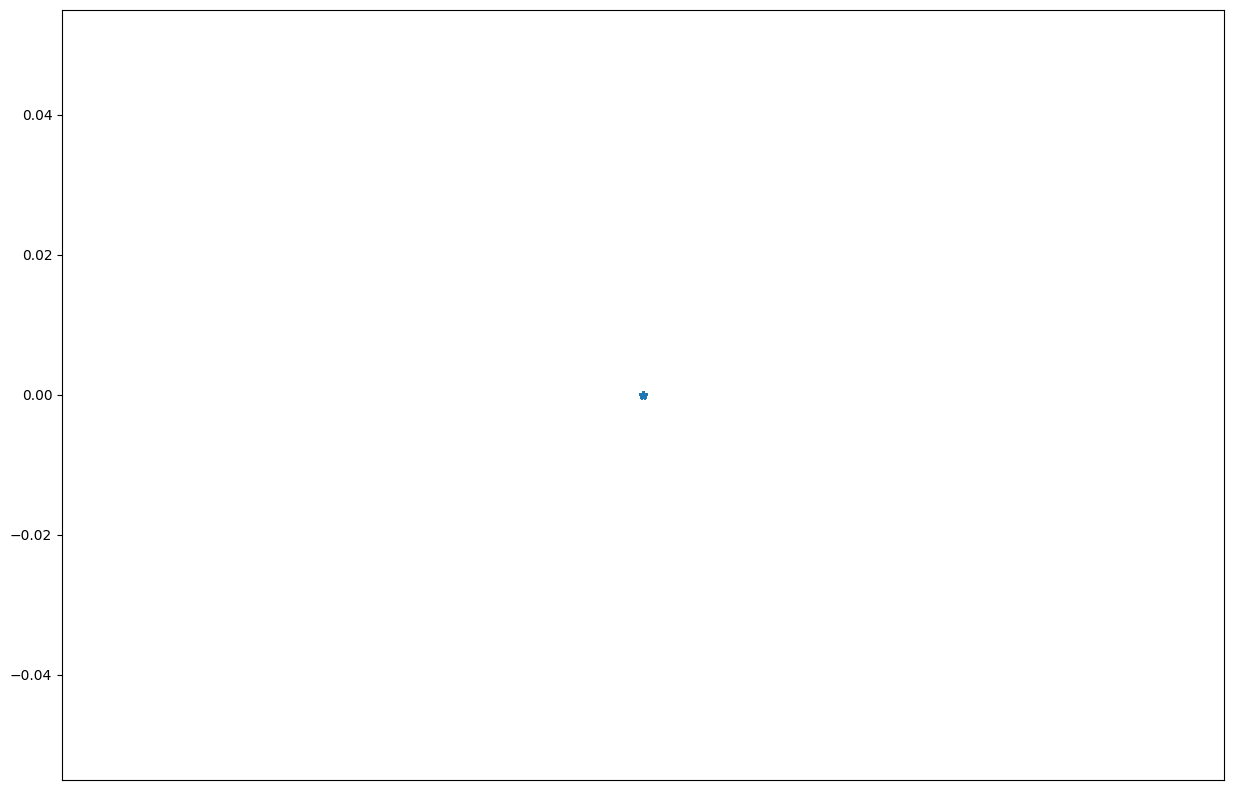

: 

In [69]:
from torch_utils import froc


for i in range(1, config["num_of_exp"] + 1):
    torch.cuda.empty_cache()
    print("#RUN", i)
    checkpoint = torch.load(config["pretrain_encoder_checkpoint"])

    basemodel = SiameseNetwork101()
    basemodel.load_state_dict(checkpoint["model_state_dict"])
    encoder = basemodel.cnn1
    del encoder.fc
    model = return_fasterrcnn_resnet50_fpn(
        num_classes = 2, 
        size = (450, 200),
        norm = True,
        pretrained=False, 
        coco_model= False,
        loss_type = 'mix'
        )

    model.backbone.body.load_state_dict(encoder.state_dict())

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=0.001)
    model.to(device)
    
    for epoch in range(config["num_epoch"]):
        torch.cuda.empty_cache()
        model.train()
        batch_loss_list = []
        batch_loss_cls_list = []
        batch_loss_box_reg_list = []
        batch_loss_objectness_list = []
        batch_loss_rpn_list = []

        
        warmup_factor = 1.0 / 1000
        warmup_iters = min(1000, len(train_loader) - 1)

        lr_scheduler = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=warmup_factor, total_iters=warmup_iters
        )
        step_counter = 0
        for images, targets in tqdm(train_loader):
            step_counter += 1
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            loss_value = losses.item()
            losses.backward()
            optimizer.step()
            lr_scheduler.step()
            batch_loss_list.append(loss_value)
            batch_loss_cls_list.append(loss_dict['loss_classifier'].detach().cpu())
            batch_loss_box_reg_list.append(loss_dict['loss_box_reg'].detach().cpu())
            batch_loss_objectness_list.append(loss_dict['loss_objectness'].detach().cpu())
            batch_loss_rpn_list.append(loss_dict['loss_rpn_box_reg'].detach().cpu())
        print(f"E {epoch}: Training Overall Loss: {sum(batch_loss_list)/len(batch_loss_list)}, Cls Loss: {sum(batch_loss_cls_list)/len(batch_loss_cls_list)}, \
            Box Loss: {sum(batch_loss_box_reg_list)/len(batch_loss_box_reg_list)}, objectness Loss: {sum(batch_loss_objectness_list)/len(batch_loss_objectness_list)}, \
            RPN Loss: {sum(batch_loss_rpn_list)/ len(batch_loss_rpn_list)}")

        torch.cuda.empty_cache()
        target = []
        preds = []
        for images, targets in tqdm(valid_loader):
            torch.cuda.empty_cache()
            model.eval()
            images = list(img.to(device) for img in images)
            with torch.no_grad():
                outputs = model(images)
            for i in range(len(images)):
                true_dict = dict()
                preds_dict = dict()
                true_dict['boxes'] = targets[i]['boxes'].detach().cpu()
                true_dict['labels'] = targets[i]['labels'].detach().cpu()
                preds_dict['boxes'] = outputs[i]['boxes'].detach().cpu()
                preds_dict['scores'] = outputs[i]['scores'].detach().cpu()
                preds_dict['labels'] = outputs[i]['labels'].detach().cpu()

                preds.append(preds_dict)
                target.append(true_dict)
            outputs = [{k: v.to(torch.device("cpu")) for k, v in t.items()} for t in outputs]

        metric = froc.FROC(2, ['__background__', 'Mass'], threshold=[0.25,0.5,1,2,4], view ='all')
        metric_summary = metric.compute(preds,target)
        print(metric_summary)

